In [58]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier,plot_importance
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score,precision_recall_curve, accuracy_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
import shap
sns.set_style("darkgrid")
path = kagglehub.dataset_download("brycecf/give-me-some-credit-dataset")
train_path = os.path.join(path,'cs-training.csv')
test_path = os.path.join(path,'cs-test.csv')
df = pd.read_csv(train_path,index_col=0)
test_df = pd.read_csv(test_path,index_col=0)

Using Colab cache for faster access to the 'give-me-some-credit-dataset' dataset.


# Identifying Missing Values and Outliers

In [2]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

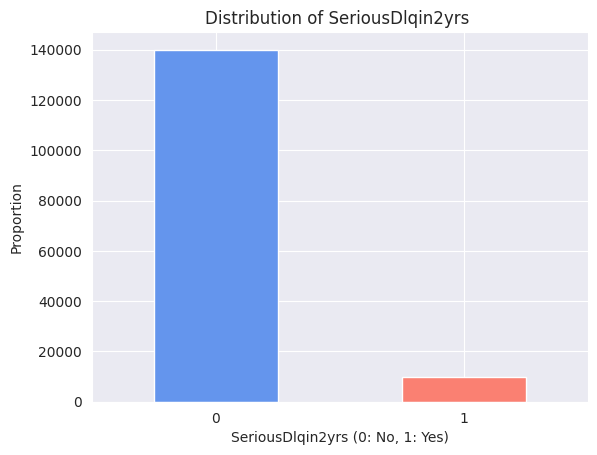

In [59]:
deliqnency = df["SeriousDlqin2yrs"].value_counts()
deliqnency.plot(kind='bar', color=['cornflowerblue', 'salmon'])

plt.title('Distribution of SeriousDlqin2yrs ')
plt.xlabel('SeriousDlqin2yrs (0: No, 1: Yes)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)

The monthly income missing values ratio: 20%
The number of dependents missing values ratio: 3%


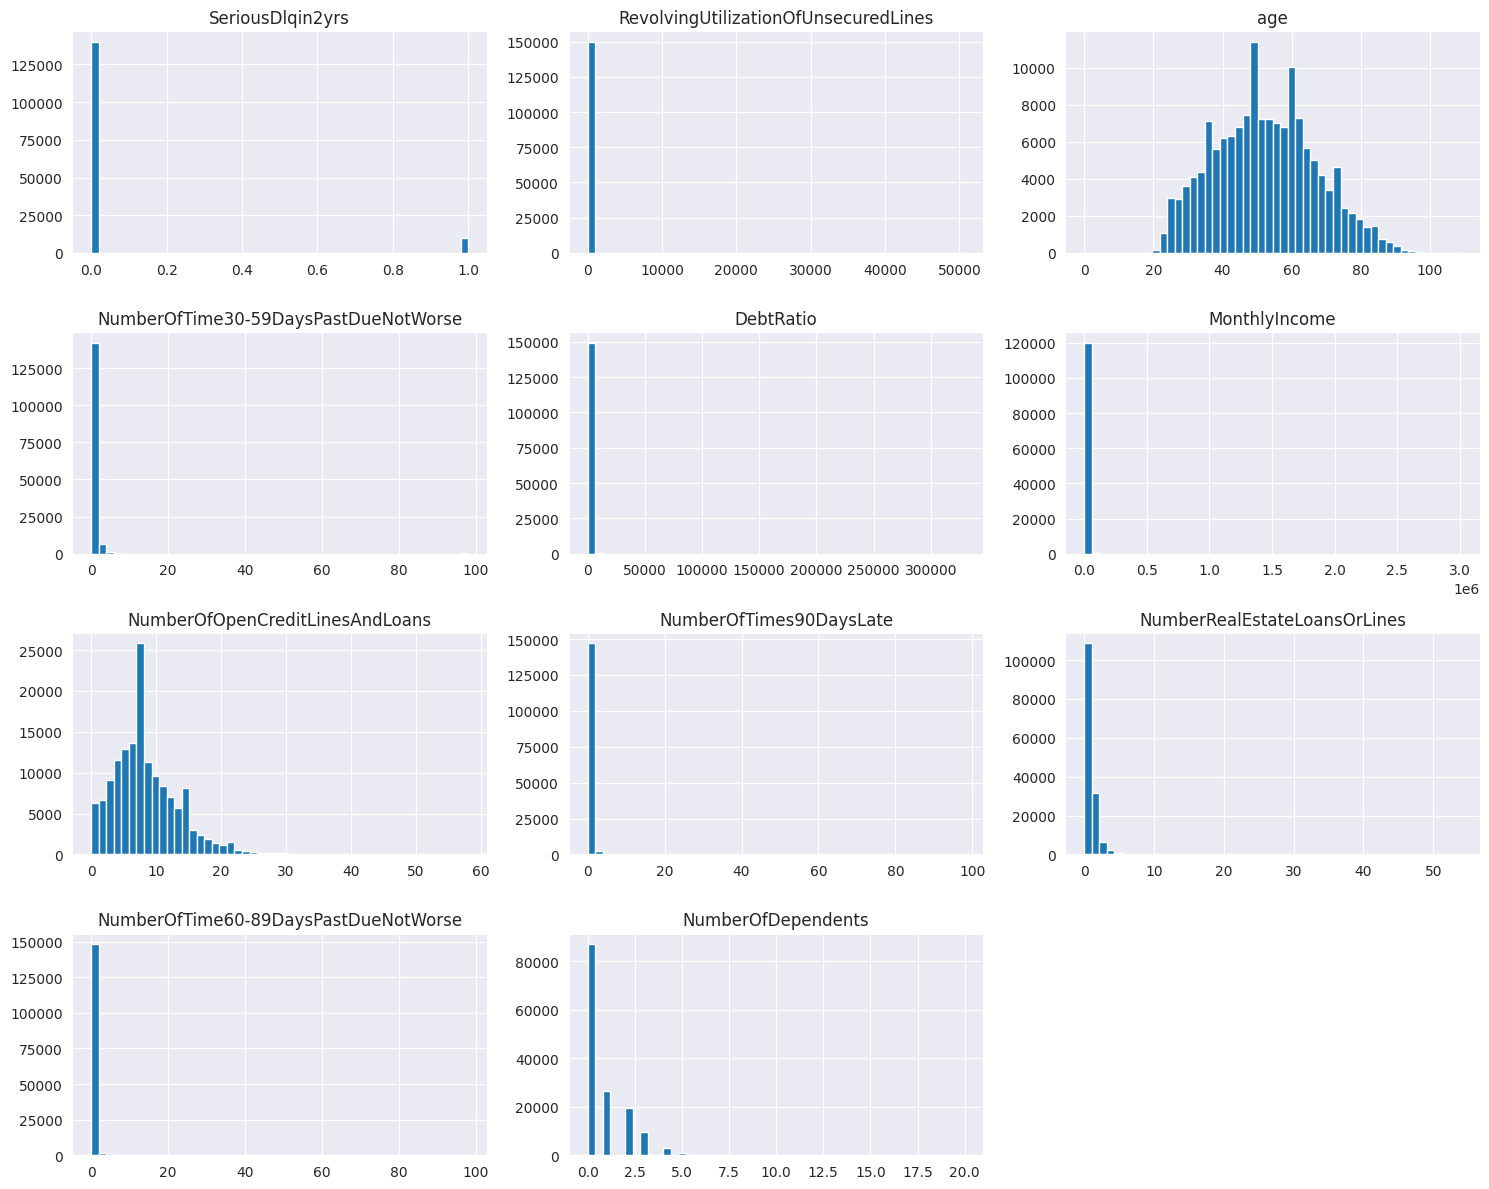

In [60]:
# print(df.isnull().sum())
print(f"The monthly income missing values ratio: {round(df["MonthlyIncome"].isnull().sum() / len(df)*100)}%")
print(f"The number of dependents missing values ratio: {round(df["NumberOfDependents"].isnull().sum() / len(df)*100)}%")

df.hist(figsize=(15, 12), bins=50)
plt.tight_layout()
plt.show()

# Feature Engineering

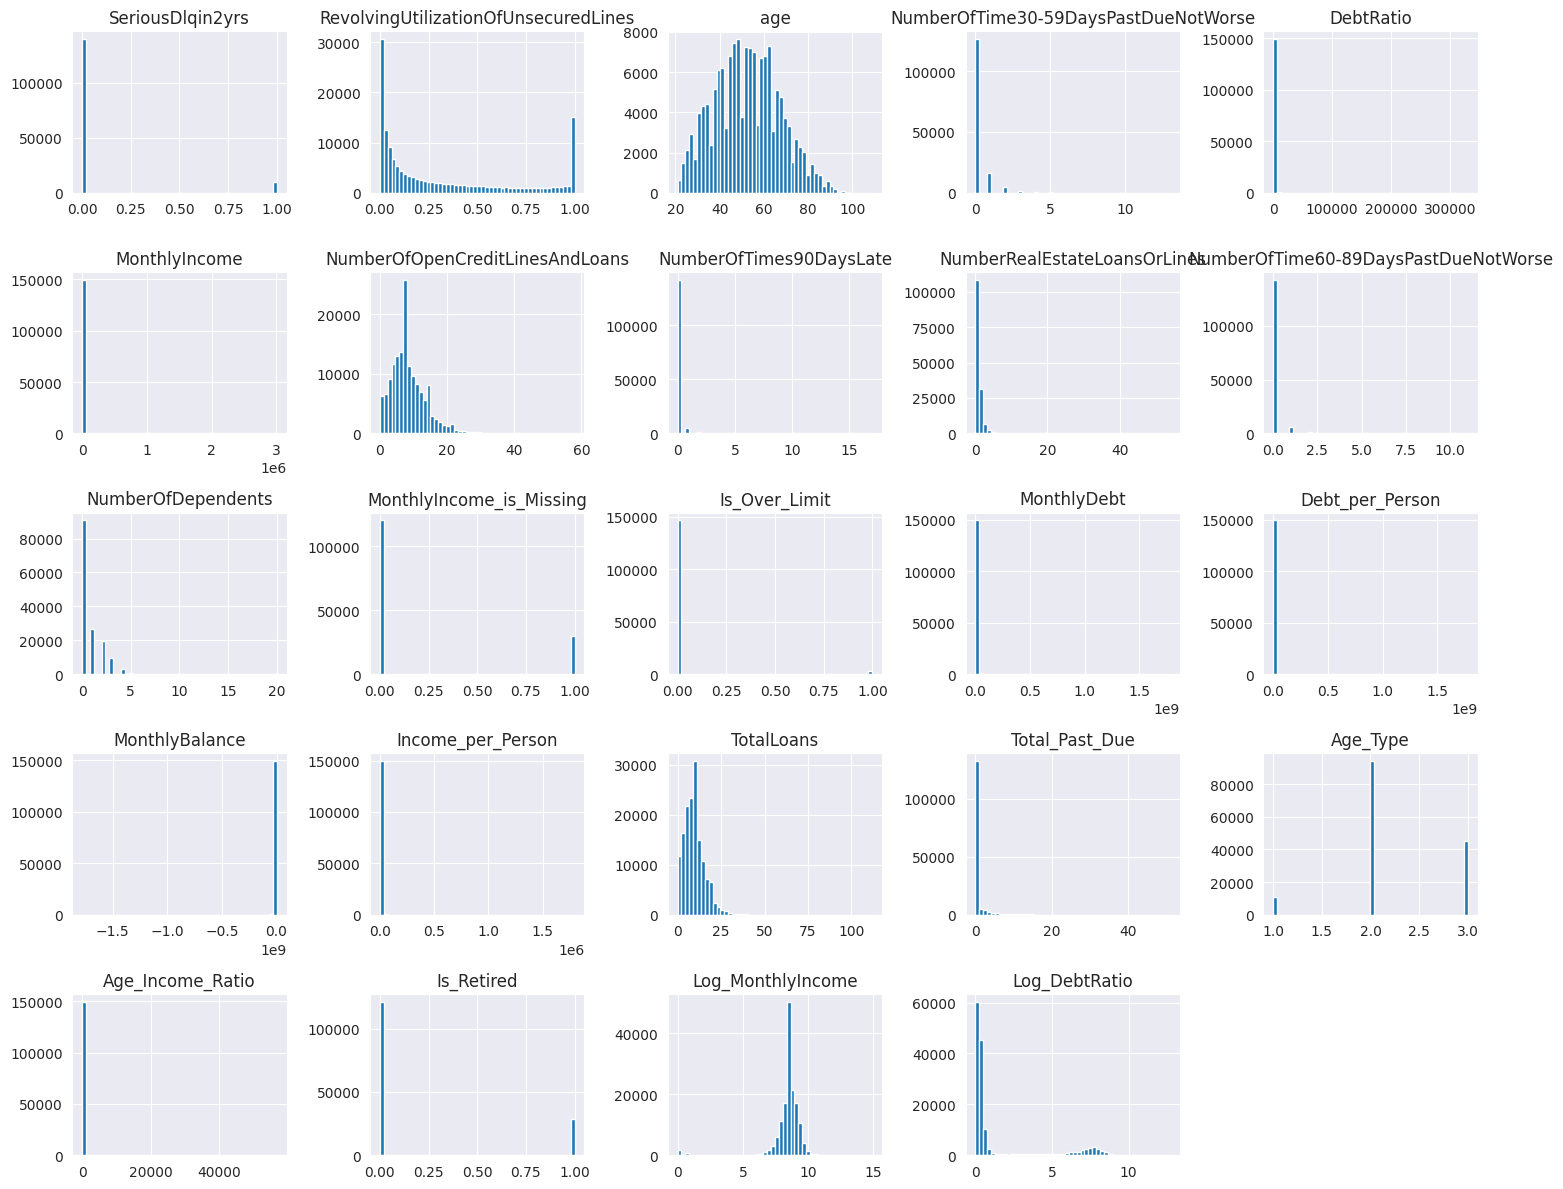

In [61]:
def preprocessor(df):
    df["MonthlyIncome_is_Missing"] = df["MonthlyIncome"].isnull().astype(int)

    df.loc[df['age'] < 18, 'age'] = df['age'].median()
    past_due_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate"
    ]
    for col in past_due_cols:
        df.loc[df[col] > 90, col] = df[col].median()

    df["Is_Over_Limit"] = (df["RevolvingUtilizationOfUnsecuredLines"] > 1).astype(int)
    df.loc[df["RevolvingUtilizationOfUnsecuredLines"] > 1, "RevolvingUtilizationOfUnsecuredLines"] = 1

    df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
    df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())


    df["MonthlyDebt"] = df["MonthlyIncome"] * df["DebtRatio"]
    df["Debt_per_Person"] = df["MonthlyDebt"] / (df["NumberOfDependents"] + 1)
    df["MonthlyBalance"] = df["MonthlyIncome"] - df["MonthlyDebt"]
    df["Income_per_Person"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

    df["TotalLoans"] = df["NumberRealEstateLoansOrLines"] + df["NumberOfOpenCreditLinesAndLoans"]
    df["Total_Past_Due"] = (df["NumberOfTime30-59DaysPastDueNotWorse"] * 1) + \
                           (df["NumberOfTime60-89DaysPastDueNotWorse"] * 2) + \
                           (df["NumberOfTimes90DaysLate"] * 3)

    df["Age_Type"] = pd.cut(df["age"], bins=[0, 30, 60, 150], labels=[1, 2, 3]).astype(int)
    df["Age_Income_Ratio"] = df["MonthlyIncome"] / (df["age"] + 1)
    df["Is_Retired"] = (df["age"]>65).astype(int)


    df['Log_MonthlyIncome'] = np.log1p(df['MonthlyIncome'])
    df['Log_DebtRatio'] = np.log1p(df["DebtRatio"])

    return df

df = preprocessor(df)
test_df = preprocessor(test_df)

df.hist(figsize=(15, 12), bins=50)
plt.tight_layout()
plt.show()

# Correlation Analysis

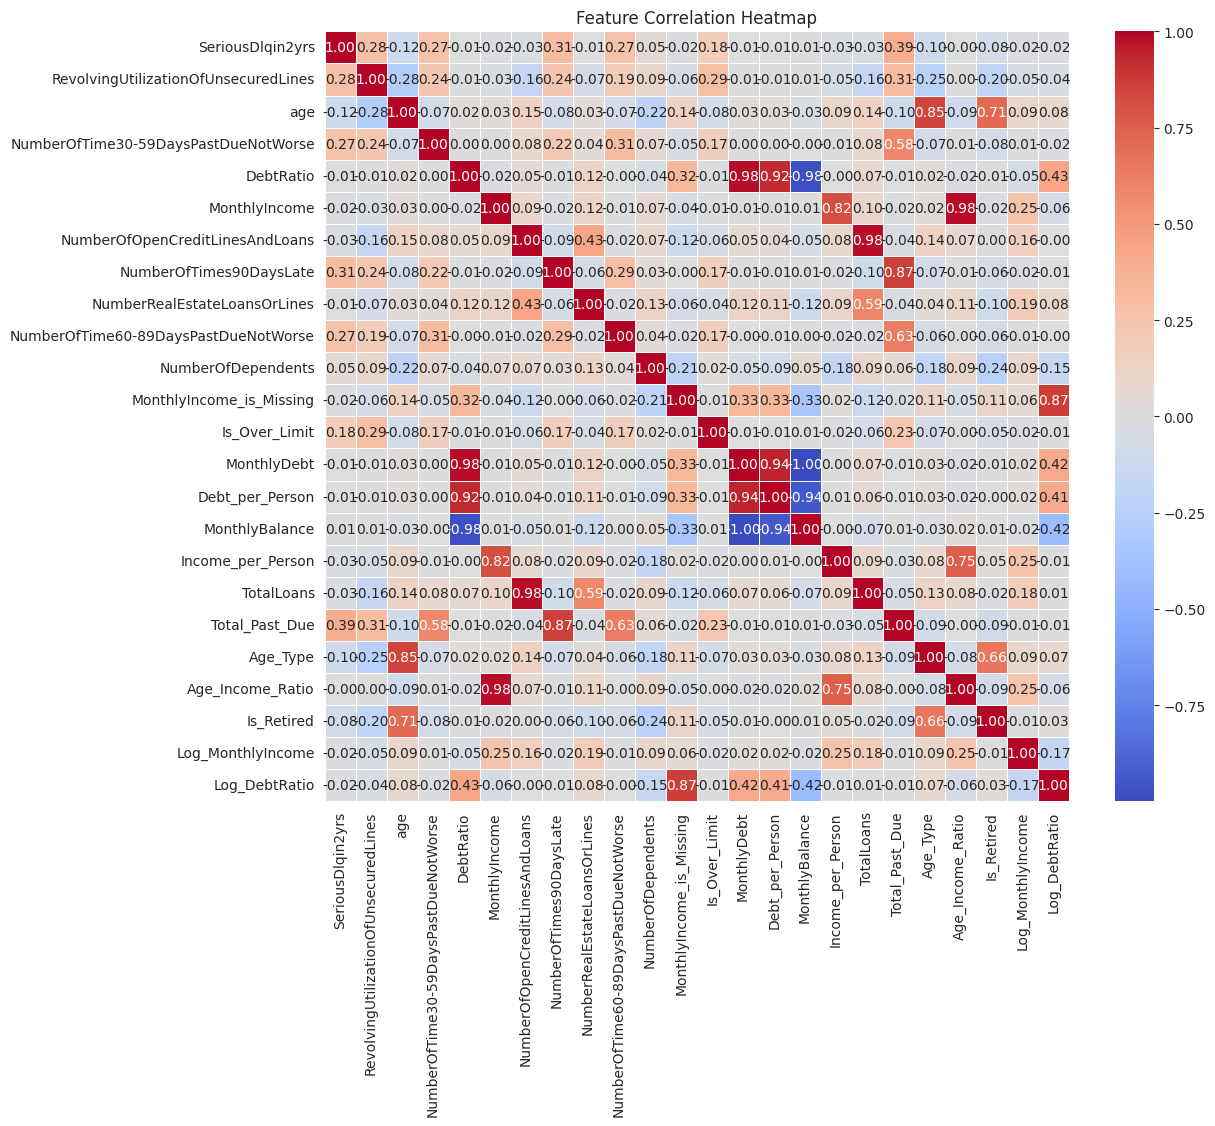

In [62]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Feature Selection

In [63]:
features = [
    "Total_Past_Due","NumberOfTimes90DaysLate","RevolvingUtilizationOfUnsecuredLines","NumberOfTime30-59DaysPastDueNotWorse","NumberOfTime60-89DaysPastDueNotWorse","age",
    "DebtRatio","TotalLoans","Log_MonthlyIncome","Is_Over_Limit"]

X = df[features]
y = df['SeriousDlqin2yrs']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("The training data size:", X_train.shape)
print("The testing data size::", X_test.shape)
print("\n The delinquency data distribution:\n", y_train.value_counts(normalize=True)) # normalize means transforming frequency into percentage

The training data size: (120000, 10)
The testing data size:: (30000, 10)

 The delinquency data distribution:
 SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


# Model Training and Evaluation



In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model Comparison
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=130,max_depth=5,class_weight='balanced',random_state=42),
    "XGBoost": XGBClassifier(n_estimators=130,learning_rate=0.05,max_depth=5,scale_pos_weight=15,random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=130, learning_rate=0.05, max_depth=5, scale_pos_weight=15, random_state=42, verbosity=-1)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

df_results = pd.DataFrame(results).sort_values(by="AUC", ascending=False)
df_results

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Recall,F1-Score,AUC
3,LightGBM,0.781200,0.796509,0.327321,0.869501
2,XGBoost,0.779867,0.792020,0.324744,0.868914
1,Random Forest,0.806067,0.768080,0.346145,0.862597
0,Logistic Regression,0.799267,0.756110,0.334880,0.858299


In [37]:
lgbm = LGBMClassifier(
    n_estimators=130,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=15,
    random_state=42,
    verbosity=-1
)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)


lgbm.fit(X_train,y_train)
lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# ROC

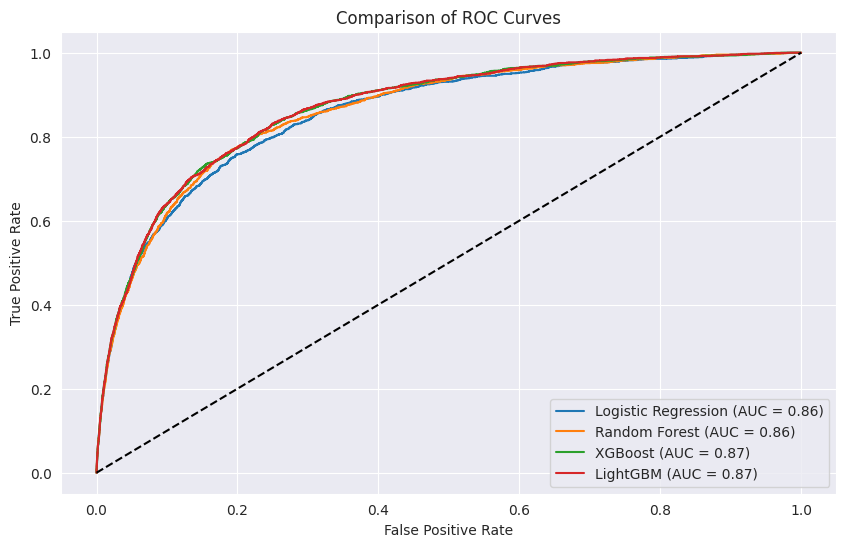

In [30]:
plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend()
plt.show()

In [23]:
def final_credit_decision(model, data, threshold=0.35):

    probs = model.predict_proba(data)[:, 1]

    decisions = (probs >= threshold).astype(int)

    result = pd.DataFrame({
        'Delinquency Ratio': probs,
        'Predicted Result': ['Reject' if d == 1 else 'Accept' for d in decisions]
    })

    return result

sample_customers = X_test.head(5)
print(final_credit_decision(lgbm, sample_customers, threshold=0.35))

   Delinquency Ratio Predicted Result
0           0.093633           Accept
1           0.301049           Accept
2           0.057884           Accept
3           0.135323           Accept
4           0.141715           Accept


# Feature Importance

In [39]:
# Logistic Regression
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
2,RevolvingUtilizationOfUnsecuredLines,2.109710
0,Total_Past_Due,0.364570
9,Is_Over_Limit,0.265301
4,NumberOfTime60-89DaysPastDueNotWorse,0.213754
3,NumberOfTime30-59DaysPastDueNotWorse,0.196055
7,TotalLoans,0.039636
6,DebtRatio,-0.000050
5,age,-0.019874
8,Log_MonthlyIncome,-0.030023
1,NumberOfTimes90DaysLate,-0.086331


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


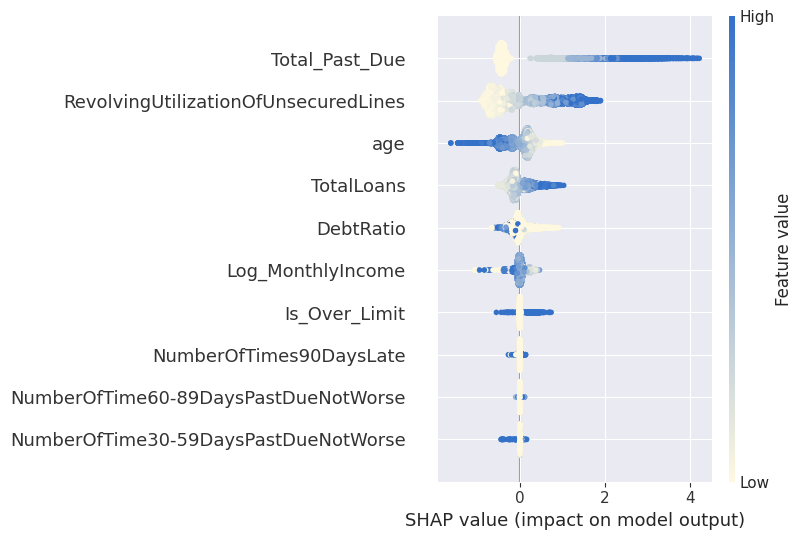

In [57]:
# SHAP
explainer = shap.TreeExplainer(lgbm)
my_cmap = clr.LinearSegmentedColormap.from_list("custom_style", ['#FEF8E0', '#3471C9'])

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test,cmap=my_cmap)

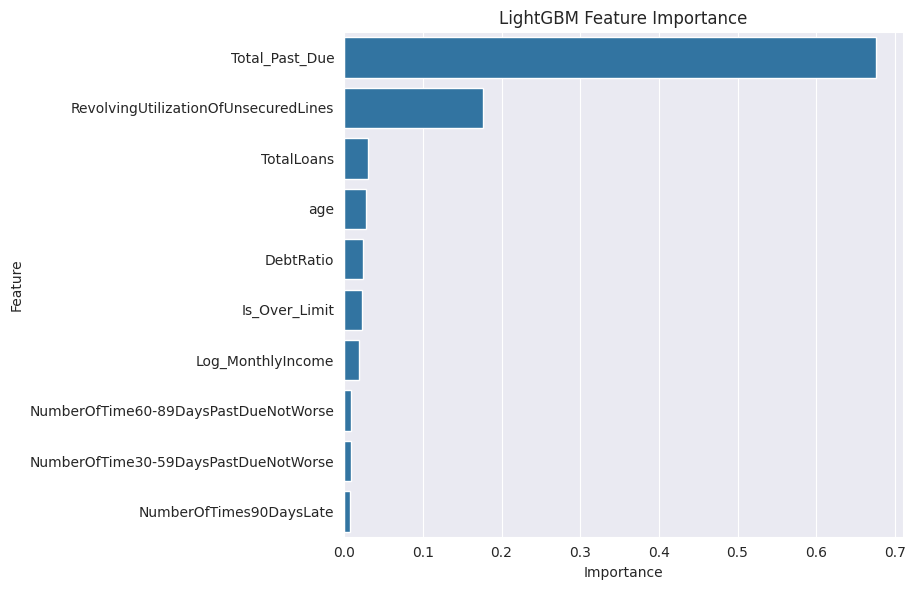

In [ ]:
# lgbm_importance = pd.DataFrame({'Feature': X.columns, 'Importance': lgbm.feature_importances_})

# lgbm_importance = lgbm_importance.sort_values(by='Importance', ascending=False)

# plt.figure(figsize=(15,6))
# plt.subplot(1, 2, 2)
# sns.barplot(x='Importance', y='Feature', data=lgbm_importance)
# plt.title('LightGBM Feature Importance')

# plt.tight_layout()
# plt.show()

# Handling Unbalanced Data

Using SMOTE method doesn't always have a better result, so we need to test out and try more.

In [ ]:
# print("Before:", Counter(y_train))

# smote = SMOTE(random_state=42)

# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# print("After:", Counter(y_train_res))

Before: Counter({0: 111979, 1: 8021})
After: Counter({0: 111979, 1: 111979})


# GridSearch

It takes time to proceed, so comment it out only when needed.

In [ ]:
# param_grid = {
#     'max_depth': [3, 5, 10],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators': [100, 150, 200,250]
# }


# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     scoring='roc_auc',
#     cv=5,
#     verbose=1
# )

# grid_search.fit(X_train_res, y_train_res)

# # 5. 輸出結果
# print(grid_search.best_params_)
# print(f" AUC Score: {grid_search.best_score_:.4f}")

# For Kaggle Submission (Not neccessary)

In [ ]:
# X_kaggle_test = test_df[X.columns]

# X_kaggle_test = X_kaggle_test.fillna(X_train.median())

# kaggle_probs = lgbm.predict_proba(X_kaggle_test)[:, 1]

# submission = pd.DataFrame({
#     'Id': test_df.index,
#     'Probability': kaggle_probs
# })

# submission.to_csv('submission.csv', index=False)